In [1]:
#%pip install numpy matplotlib

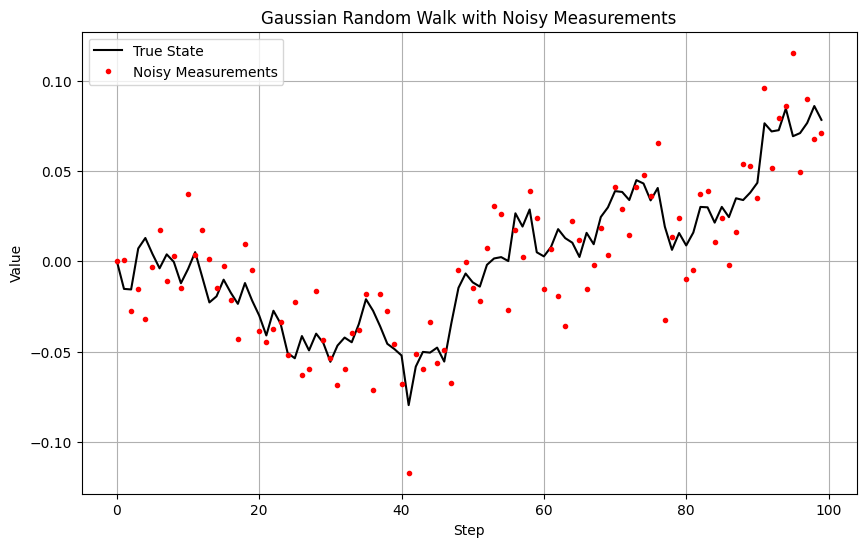

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate random Gaussian walk process with noisy measurements

steps = 100

Q = 0.01
R = 0.02

x = np.empty(steps)
y = np.empty(steps)

x[0] = 0

# Generate simulation
for k in range(1, steps):
    x[k] = x[k-1] + np.random.normal(0, Q)
    y[k] = x[k] + np.random.normal(0, R)

# Plot the true values (x) and the noisy measurements (y)
plt.figure(figsize=(10, 6))

# Plot the true state (x)
plt.plot(x, '-', label='True State', color='black')

# Plot the noisy measurements (y)
plt.plot(y, '.', label='Noisy Measurements', color='red')

# Labels and title
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Gaussian Random Walk with Noisy Measurements')

# Enable grid
plt.grid(True)

# Show legend
plt.legend()

# Display the plot
plt.show()


In [3]:
# Implement a KF of the process

def KF(y, Q, R, steps):

    m = np.empty(steps)
    P = np.empty(steps)

    m[0] = 0.01
    P[0] = 0.1
    
    for k in range(1, steps):
        # Prediction
        m_ = m[k-1]
        P_ = P[k-1] + Q

        # Update
        S = P_ + R
        K = P_ / S
        m[k] = m_ + K*(y[k] - m_)
        P[k] = P_ - K*S*K

    return m, P

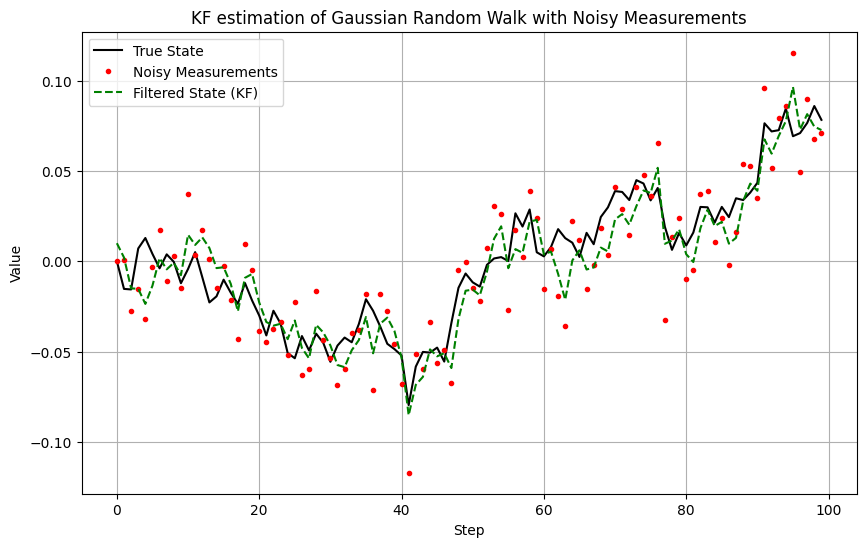

In [4]:
# Simulate KF of process

m_kf, P_kf = KF(y, Q, R, steps)

# Plot the true values (x), the noisy measurements (y) and the KF estimates (m) with covariances (P)
plt.figure(figsize=(10, 6))

# Plot the true state (x)
plt.plot(x, '-', label='True State', color='black')

# Plot the noisy measurements (y)
plt.plot(y, '.', label='Noisy Measurements', color='red')

# Plot the filtered state (m)
plt.plot(m_kf, '--', label='Filtered State (KF)', color='green')

# Plot the 1-SD confidence interval
#plt.fill_between(range(steps), m_kf - np.sqrt(P_kf), m_kf + np.sqrt(P_kf), color='green', alpha=0.3, label='1-SD Confidence Interval')


# Labels and title
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('KF estimation of Gaussian Random Walk with Noisy Measurements')

# Enable grid
plt.grid(True)

# Show legend
plt.legend()

# Display the plot
plt.show()

In [5]:
rmse = np.sqrt(np.mean((m_kf - x)**2))
print(f"KF RMSE: {rmse:.4f}")

KF RMSE: 0.0131
